In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import torchvision


In [2]:
class CIFAR10DataModule:
    def __init__(self,
                 data_dir="./data",
                 batch_size=64,
                 num_workers=2,
                 normalize=True):

        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

        # Define transforms
        if normalize:
            self.transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5),
                                     (0.5, 0.5, 0.5))
            ])
        else:
            self.transform = transforms.ToTensor()

    def setup(self):
        """Download and prepare datasets."""
        self.train_dataset = datasets.CIFAR10(
            root=self.data_dir,
            train=True,
            download=True,
            transform=self.transform
        )

        self.test_dataset = datasets.CIFAR10(
            root=self.data_dir,
            train=False,
            download=True,
            transform=self.transform
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )


In [3]:
data = CIFAR10DataModule(batch_size=128)
data.setup()

train_loader = data.train_dataloader()
test_loader = data.test_dataloader()

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)


torch.Size([128, 3, 32, 32]) torch.Size([128])


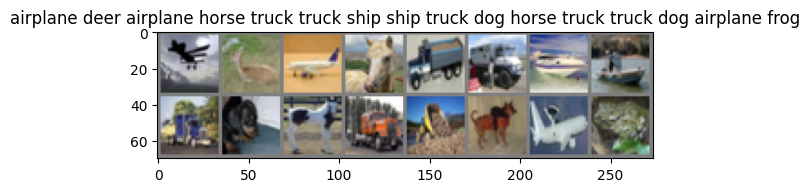

In [4]:
trainset = torchvision.datasets.CIFAR10(root='./data',
                                        train=True,
                                        download=True,
                                        transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))
trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=16,
                                          shuffle=True)
images, labels = next(iter(trainloader))
plt.imshow(torchvision.utils.make_grid(images).permute(1, 2, 0) / 2 + 0.5);
plt.title(' '.join(trainset.classes[label] for label in labels));
plt.show()